In [1]:
import sys,os
sys.path.append('../')

from GraphDQN import GraphDQN
from tqdm import tqdm
import numpy as np
import time
import networkx as nx
import pandas as pd
import json
import argparse
import matplotlib.pyplot as plt
from testUtils import load_config, create_model, load_synthetic_graphs, detailed_result_dir, load_real_graph,_get_synth_param_grid
from testUtils import load_real_csv,load_synth_csv

# Model configurations to compare
model_BA_params_configs = {'nrange_list':['30_50','50_100'],
                            'm_list':[1,2,3,4,5,6]}
model_g_type_configs = ['BA']
model_gnn_configs = ['graphSage']

# Generate all model configurations
all_model_configs = []

for g_type in model_g_type_configs:
    for gnn in model_gnn_configs:
        if g_type == 'BA':
             for nrange in model_BA_params_configs['nrange_list']:
                for m in model_BA_params_configs['m_list']:
                    g_params = {
                        'nrange': nrange,
                        'm': m
                    }
                    model_config = {
                        "g_type": g_type,
                        "gnn_model": gnn,
                        "target_graph": "Digg",
                        "g_params": g_params,
                        "save_model_dir": "./models"
                    }
                    all_model_configs.append(model_config)
        if g_type == 'ego':
            pass

In [2]:
# functions in testModels

def max_cc_to_xy(MaxCCList, plot_step_ratio=0.005):
    """
    Convert MaxCCList to x,y for plotting
    Parameters:
    - MaxCCList: list of MaxCC values
    - plot_step_ratio: ratio of plot step to MaxCCList length
    Returns:
    - x: list of x values
    - y: list of y values
    """
    MaxCCList = np.array(MaxCCList)
    plot_step = max(1,np.floor(len(MaxCCList) * plot_step_ratio))
    x = np.arange(0,len(MaxCCList),plot_step).astype(int)
    if x[-1] != len(MaxCCList)-1:
        x = np.append(x, len(MaxCCList)-1)
    y = MaxCCList[x]
    x = x / (len(MaxCCList)-1)
    return x,y

def plot_max_cc_comparison(all_results, model_configs):
    """
    Plot MaxCC comparison for different models on the same dataset/graph
    
    Parameters:
    - all_results: dict {dataset:{model_key:model_results}}
    - dataset: name of the dataset or configuration
    - save_dir: directory to save the plot
    - model_configs: list of model configurations for labels
    """
    plt.figure(figsize=(10, 6))
    
    for dataset,dataset_results in all_results.items():
        print(f"Plotting MaxCC comparison on {dataset}")
        
        # Colors for different models
        colors = plt.cm.tab20(np.linspace(0, 1, len(dataset_results)))

        for i, (model_key, results) in enumerate(dataset_results.items()):
            if results['MaxCCList'] is not None:
                # Extract model index from model_key (e.g., "model_1" -> 1)
                model_idx = int(model_key.split('_')[1])
                model_config = model_configs[model_idx-1]
                
                # Create model label
                g_type = model_config['g_type']
                gnn = model_config['gnn_model']
                if g_type == 'BA':
                    nrange = model_config['g_params']['nrange']
                    m = model_config['g_params']['m']
                    label = f"model_{gnn}_{g_type}_nrange_{nrange}_m_{m}"
                else:
                    label = f"model_{gnn}_{g_type}"
                
                # Plot MaxCC curve
                MaxCCList = np.array(results['MaxCCList'])
                x,y = max_cc_to_xy(MaxCCList)
                plt.plot(x, y, color=colors[i], linewidth=2, label=label, marker='o', markersize=3)
    
        plt.xlabel('Removal Ratio')
        plt.ylabel('Maximum Connected Component Size')
        plt.title(f'Dataset : {dataset}')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Save plot
        plt.show()

Evaluating models:   0%|          | 0/12 [00:00<?, ?it/s]

GPU detected: 1 device(s) available, Using device: /physical_device:GPU:0
tf.is_gpu_available() : True

Finding best model by validation score: graphSage_iter_60000.ckpt
restore model from ../models/BA_nrange_30_50_m_1\graphSage_iter_60000.ckpt successfully
testing
number of nodes:30
number of edges:29
Iteration:0
Iteration:1
Iteration:2
Iteration:3
Iteration:4
Iteration:5
Iteration:6
Iteration:7
number of nodes:30
number of edges:29
number of sol nodes:8
number of solution nodes:30


Evaluating models:   8%|▊         | 1/12 [00:01<00:21,  1.93s/it]

GPU detected: 1 device(s) available, Using device: /physical_device:GPU:0
tf.is_gpu_available() : True

Finding best model by validation score: graphSage_iter_67800.ckpt
restore model from ../models/BA_nrange_30_50_m_2\graphSage_iter_67800.ckpt successfully
testing
number of nodes:30
number of edges:29
Iteration:0
Iteration:1
Iteration:2
Iteration:3
Iteration:4
Iteration:5
Iteration:6
Iteration:7
number of nodes:30
number of edges:29
number of sol nodes:8
number of solution nodes:30


Evaluating models:  17%|█▋        | 2/12 [00:03<00:18,  1.81s/it]

...

GPU detected: 1 device(s) available, Using device: /physical_device:GPU:0
tf.is_gpu_available() : True

Finding best model by validation score: graphSage_iter_70200.ckpt
restore model from ../models/BA_nrange_50_100_m_5\graphSage_iter_70200.ckpt successfully
testing
number of nodes:100
number of edges:196
Iteration:0
Iteration:1
Iteration:2
Iteration:3
Iteration:4
Iteration:5
Iteration:6
Iteration:7
Iteration:8
Iteration:9
Iteration:10
Iteration:11
Iteration:12
Iteration:13
Iteration:14
Iteration:15
Iteration:16
Iteration:17
Iteration:18
Iteration:19
Iteration:20
Iteration:21
Iteration:22
Iteration:23
Iteration:24
Iteration:25
Iteration:26
Iteration:27
Iteration:28
Iteration:29
Iteration:30
Iteration:31
Iteration:32
Iteration:33
Iteration:34
Iteration:35
Iteration:36
Iteration:37
Iteration:38
Iteration:39
Iteration:40
Iteration:41
Iteration:42
Iteration:43
Iteration:44
Iteration:45
number of nodes:100
number of edges:196
number of sol nodes:46
number of solution nodes:100


Evaluating models:  92%|█████████▏| 11/12 [00:16<00:01,  1.50s/it]

GPU detected: 1 device(s) available, Using device: /physical_device:GPU:0
tf.is_gpu_available() : True

Finding best model by validation score: graphSage_iter_75600.ckpt
restore model from ../models/BA_nrange_50_100_m_6\graphSage_iter_75600.ckpt successfully
testing
number of nodes:100
number of edges:196
Iteration:0
Iteration:1
Iteration:2
Iteration:3
Iteration:4
Iteration:5
Iteration:6
Iteration:7
Iteration:8
Iteration:9
Iteration:10
Iteration:11
Iteration:12
Iteration:13
Iteration:14
Iteration:15
Iteration:16
Iteration:17
Iteration:18
Iteration:19
Iteration:20
Iteration:21
Iteration:22
Iteration:23
Iteration:24
Iteration:25
Iteration:26
Iteration:27
Iteration:28
Iteration:29
Iteration:30
Iteration:31
Iteration:32
Iteration:33
Iteration:34
Iteration:35
Iteration:36
Iteration:37
Iteration:38
Iteration:39
Iteration:40
Iteration:41
Iteration:42
number of nodes:100
number of edges:196
number of sol nodes:43
number of solution nodes:100


Evaluating models: 100%|██████████| 12/12 [00:18<00:00,  1.50s/it]


Plotting MaxCC comparison on BA_n_30_m_1


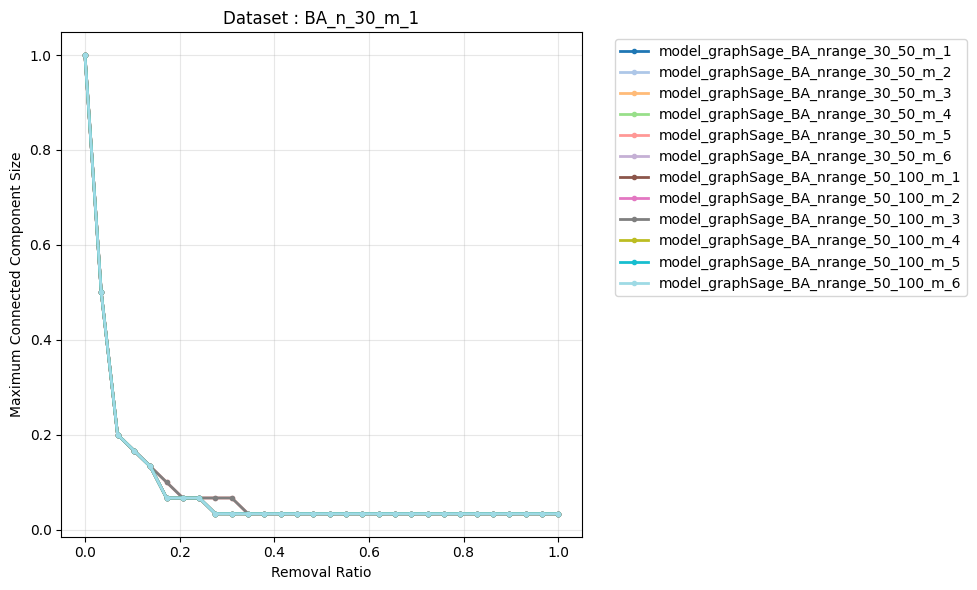

Plotting MaxCC comparison on BA_n_40_m_1


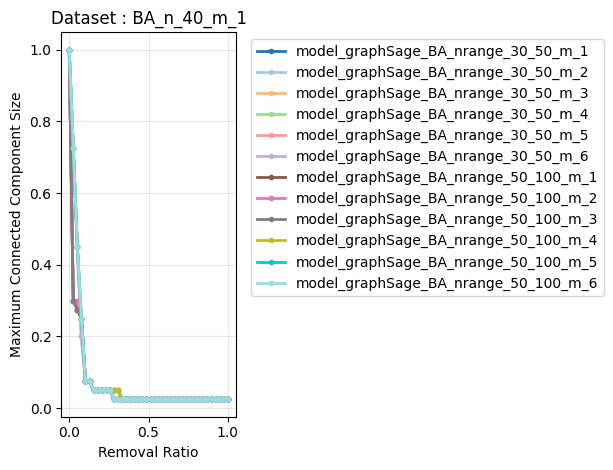

Plotting MaxCC comparison on BA_n_50_m_1


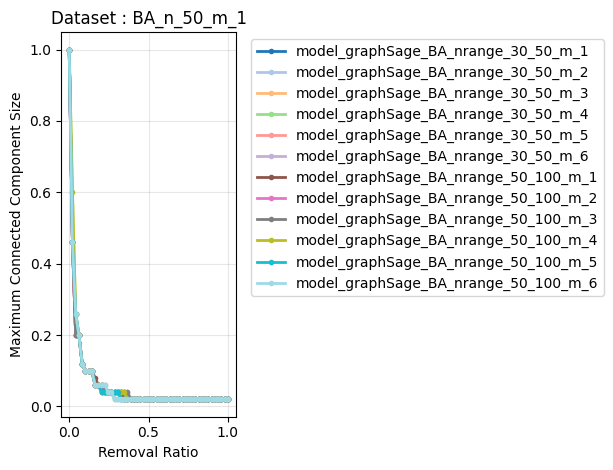

Plotting MaxCC comparison on BA_n_60_m_1


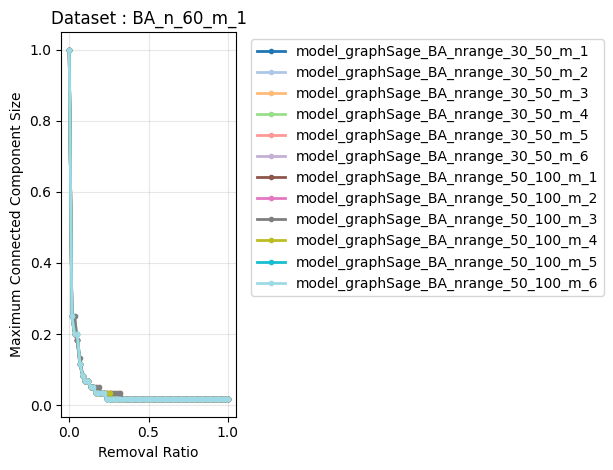

Plotting MaxCC comparison on BA_n_70_m_1


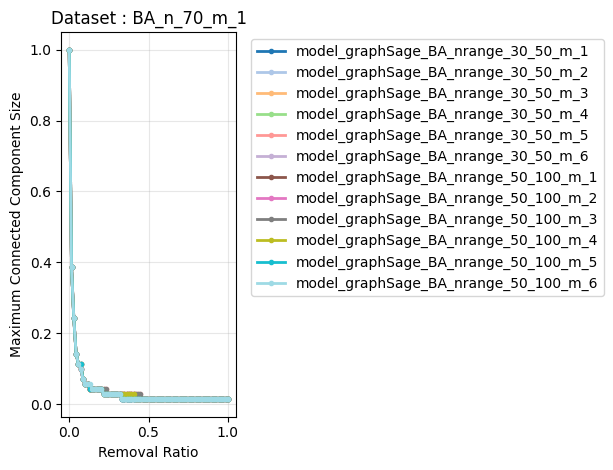

Plotting MaxCC comparison on BA_n_80_m_1


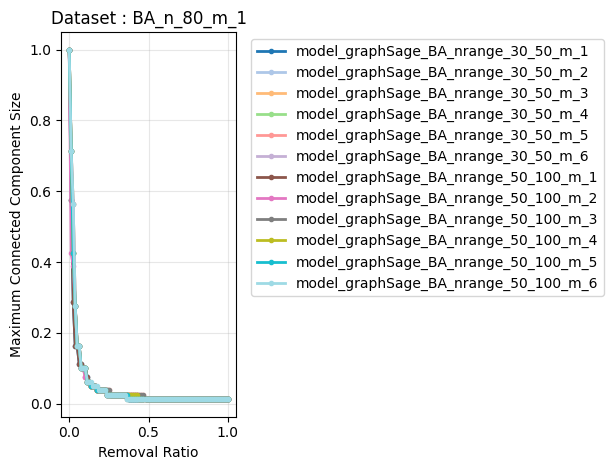

Plotting MaxCC comparison on BA_n_90_m_1


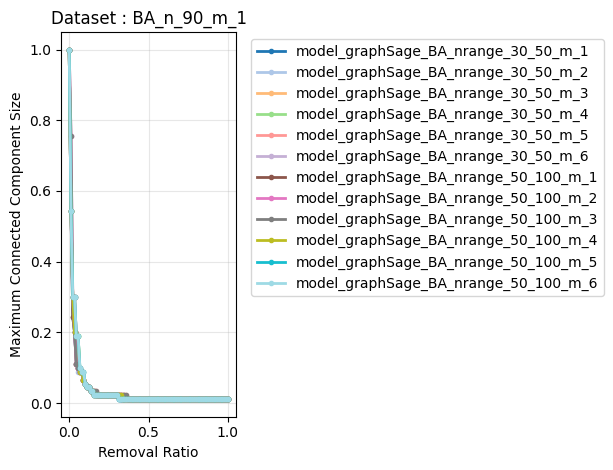

Plotting MaxCC comparison on BA_n_100_m_1


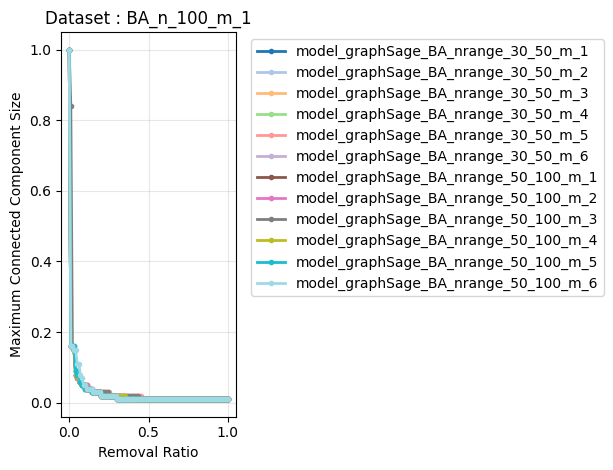

Plotting MaxCC comparison on BA_n_30_m_2


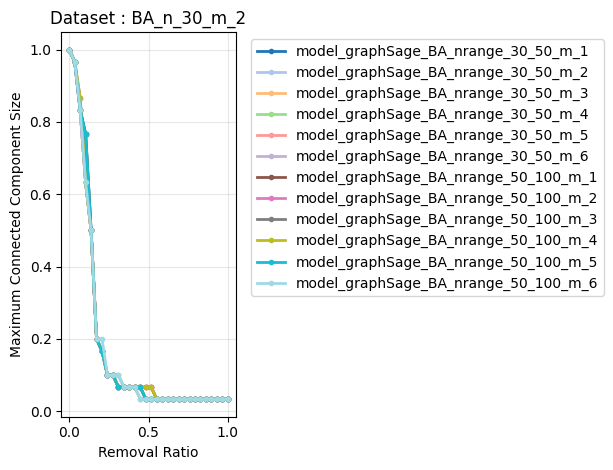

Plotting MaxCC comparison on BA_n_40_m_2


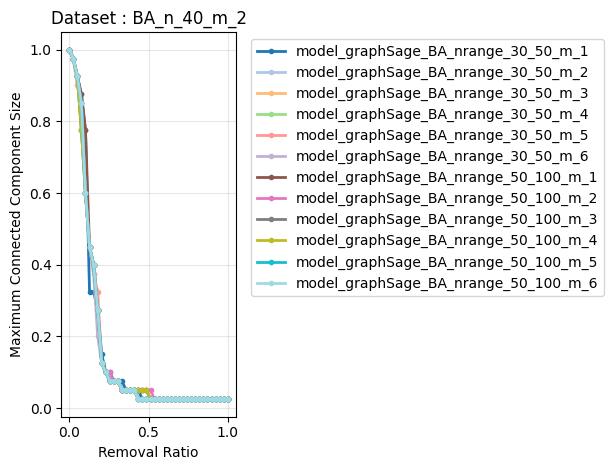

Plotting MaxCC comparison on BA_n_50_m_2


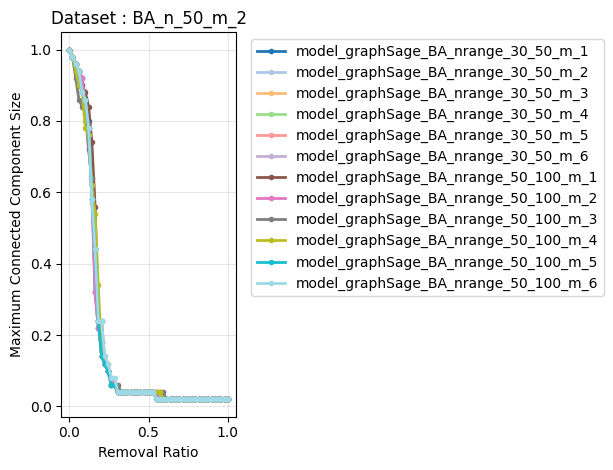

Plotting MaxCC comparison on BA_n_60_m_2


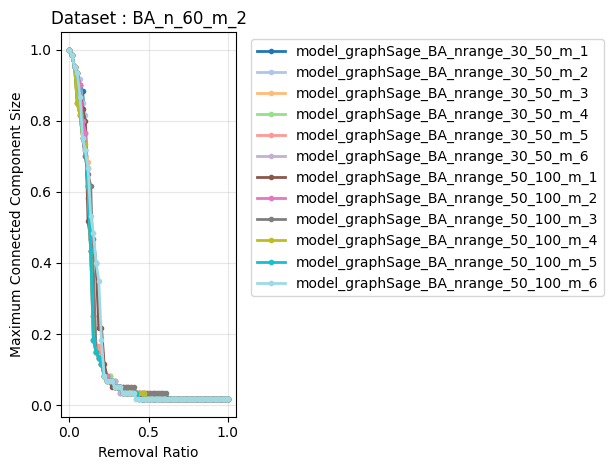

Plotting MaxCC comparison on BA_n_70_m_2


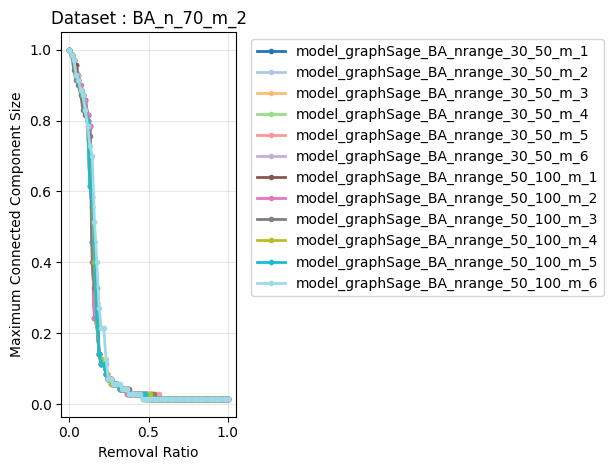

Plotting MaxCC comparison on BA_n_80_m_2


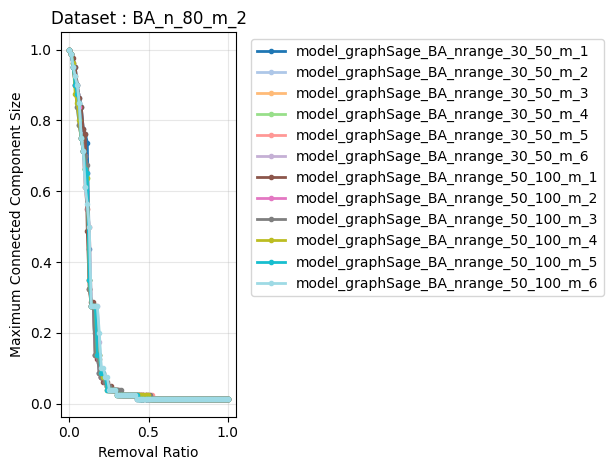

Plotting MaxCC comparison on BA_n_90_m_2


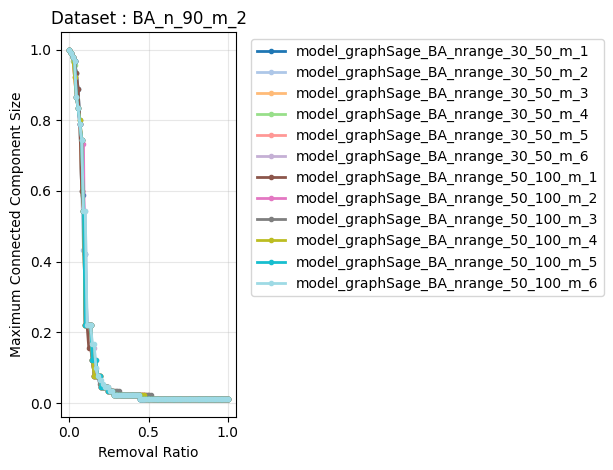

Plotting MaxCC comparison on BA_n_100_m_2


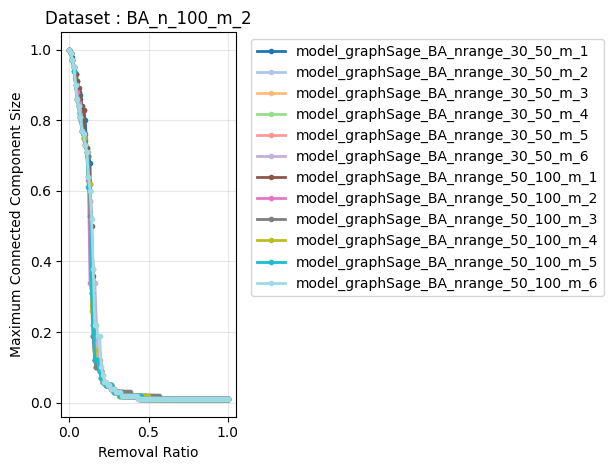

In [ ]:
%matplotlib inline


results = {}
for m in [1,2]:
    for n in [30,40,50,60,70,80,90,100]:
        synth_dataset = f'BA_n_{n}_m_{m}'
        g = nx.barabasi_albert_graph(n,m)
        results[synth_dataset] = {}
        # eval each model on synth_dataset
        for i, model_config in enumerate(tqdm(all_model_configs, desc="Evaluating models")):
            model_key = f"model_{i+1}"
            model_config['save_model_dir'] = "../models"
            # Create and load model
            dqn = create_model(model_config)
            best_ckpt_file = dqn.findModel()
            best_iter = int(best_ckpt_file.split('.ckpt')[0].split('_')[-1])
            dqn.LoadModel(best_ckpt_file)

            temp_sol_file = f"temp_synthetic.txt"

            # Get solution and evaluate
            sol, sol_time = dqn.EvaluateRealData(g, temp_sol_file, stepRatio=0.01)
            score, MaxCCList = dqn.EvaluateSol(g, temp_sol_file, strategyID = 0, reInsertStep=0.001)
            results[synth_dataset][model_key] = {
                        'score': score,
                        'time': sol_time,
                        'MaxCCList': MaxCCList,
                        'graph': g
                    }

            if os.path.exists(temp_sol_file):
                os.remove(temp_sol_file)


plot_max_cc_comparison(results, all_model_configs)

In [ ]:
%matplotlib inline

results = {}
for m in [2,3,4,5,6]:
    for n in [100,150,200,250,1000]:
        synth_dataset = f'BA_n_{n}_m_{m}'
        g = nx.barabasi_albert_graph(n,m)
        results[synth_dataset] = {}
        # eval each model on synth_dataset
        for i, model_config in enumerate(tqdm(all_model_configs, desc="Evaluating models")):
            model_key = f"model_{i+1}"
            model_config['save_model_dir'] = "../models"
            # Create and load model
            dqn = create_model(model_config)
            best_ckpt_file = dqn.findModel()
            best_iter = int(best_ckpt_file.split('.ckpt')[0].split('_')[-1])
            dqn.LoadModel(best_ckpt_file)

            temp_sol_file = f"temp_synthetic.txt"

            # Get solution and evaluate
            sol, sol_time = dqn.EvaluateRealData(g, temp_sol_file, stepRatio=0.01)
            score, MaxCCList = dqn.EvaluateSol(g, temp_sol_file, strategyID = 0, reInsertStep=0.001)
            results[synth_dataset][model_key] = {
                        'score': score,
                        'time': sol_time,
                        'MaxCCList': MaxCCList,
                        'graph': g
                    }


plot_max_cc_comparison(results, all_model_configs)